# EMIPredict AI — Intelligent Financial Risk Assessment Platform

**Domain:** FinTech & Banking | **Dataset:** 400K+ financial profiles | **Author:** Sahil Mohammed

A dual machine-learning solution for loan decisioning:

1. **Classification** — predict `emi_eligibility` (Eligible / High_Risk / Not_Eligible)
2. **Regression** — predict `max_monthly_emi` (maximum safe monthly EMI in INR)

The workflow covers data quality assessment, cleaning, EDA (15 visualizations), feature engineering,
training **3 classification + 3 regression models**, full **MLflow experiment tracking + model registry**,
and export of production models for the Streamlit application.

**Success targets:** Classification accuracy > 90% • Regression RMSE < 2000 INR

## 1. Setup & Data Loading

In [1]:
import warnings, re, os, gc, json
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn, xgboost, mlflow, joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid', palette='viridis')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', 50)

print(f"pandas {pd.__version__} | sklearn {sklearn.__version__} | xgboost {xgboost.__version__} | mlflow {mlflow.__version__}")

pandas 2.3.3 | sklearn 1.7.2 | xgboost 3.2.0 | mlflow 3.15.1


In [2]:
df_raw = pd.read_csv('emi_prediction_dataset.csv', low_memory=False)
print(f"Shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
print(f"Memory: {df_raw.memory_usage(deep=True).sum()/1e6:.1f} MB")
df_raw.head()

Shape: 404,800 rows x 27 columns
Memory: 361.6 MB


,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,family_size,dependents,school_fees,college_fees,travel_expenses,groceries_utilities,other_monthly_expenses,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi
0,38,Female,Married,Professional,82600.0,Private,0.9,Mid-size,Rented,20000.0,3,2,0.0,0.0,7200.0,19500.0,13200.0,Yes,23700.0,660.0,303200.0,70200.0,Personal Loan EMI,850000.0,15,Not_Eligible,500.0
1,38,Female,Married,Graduate,21500.0,Private,7.0,MNC,Family,0.0,2,1,5100.0,0.0,1400.0,5400.0,3500.0,Yes,4100.0,714.0,92500.0,26900.0,E-commerce Shopping EMI,128000.0,19,Not_Eligible,700.0
2,38,Male,Married,Professional,86100.0,Private,5.8,Startup,Own,0.0,4,3,0.0,0.0,10200.0,19400.0,6000.0,No,0.0,650.0,672100.0,324200.0,Education EMI,306000.0,16,Eligible,27775.0
3,58,Female,Married,High School,66800.0,Private,2.2,Mid-size,Own,0.0,5,4,11400.0,0.0,6200.0,11900.0,7900.0,No,0.0,685.0,440900.0,178100.0,Vehicle EMI,304000.0,83,Eligible,16170.0
4,48,Female,Married,Professional,57300.0,Private,3.4,Mid-size,Family,0.0,4,3,9400.0,21300.0,3600.0,16200.0,8100.0,No,0.0,770.0,97300.0,28200.0,Home Appliances EMI,252000.0,7,Not_Eligible,500.0


In [3]:
df_raw.dtypes.to_frame('dtype').T

,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,family_size,dependents,school_fees,college_fees,travel_expenses,groceries_utilities,other_monthly_expenses,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi
dtype,object,object,object,object,object,object,float64,object,object,float64,int64,int64,float64,float64,float64,float64,float64,object,float64,float64,object,float64,object,float64,int64,object,float64


## 2. Data Quality Assessment & Preprocessing

Real-world financial data is messy. We audit the raw file first, then fix issues one class at a time,
documenting every decision — exactly what a regulated lender must do for auditability.

In [4]:
# ---- 2.1 Raw quality audit ----
quality_before = {}
miss = df_raw.isna().sum()
quality_before['missing_cells'] = int(miss.sum())
quality_before['duplicate_rows'] = int(df_raw.duplicated().sum())

# Numeric columns stored as text (mixed types)
mixed_cols = [c for c in ['age','monthly_salary','bank_balance'] if df_raw[c].dtype == object]
corrupt_counts = {}
for c in mixed_cols:
    coerced = pd.to_numeric(df_raw[c], errors='coerce')
    corrupt_counts[c] = int((coerced.isna() & df_raw[c].notna()).sum())
quality_before['corrupt_numeric_values'] = corrupt_counts
quality_before['gender_variants'] = df_raw['gender'].nunique()
quality_before['invalid_credit_scores'] = int(((df_raw['credit_score']<300)|(df_raw['credit_score']>850)).sum())
quality_before['owners_paying_rent'] = int(((df_raw['house_type']=='Own')&(df_raw['monthly_rent']>0)).sum())

print("RAW DATA QUALITY AUDIT")
print("="*50)
print(f"Missing cells:            {quality_before['missing_cells']:,}")
print(f"Duplicate rows:           {quality_before['duplicate_rows']:,}")
print(f"Corrupt numeric strings:  {corrupt_counts}")
print(f"Gender label variants:    {quality_before['gender_variants']} (should be 2)")
print(f"Invalid credit scores:    {quality_before['invalid_credit_scores']:,} (outside 300-850)")
print(f"Home owners paying rent:  {quality_before['owners_paying_rent']:,} (logical violation)")
miss[miss>0].to_frame('missing_count').assign(pct=lambda d: (d.missing_count/len(df_raw)*100).round(2))

RAW DATA QUALITY AUDIT
Missing cells:            12,027
Duplicate rows:           0
Corrupt numeric strings:  {'age': 3, 'monthly_salary': 1993, 'bank_balance': 1966}
Gender label variants:    8 (should be 2)
Invalid credit scores:    4,776 (outside 300-850)
Home owners paying rent:  2,547 (logical violation)


,missing_count,pct
education,2404,0.59
monthly_rent,2426,0.60
credit_score,2420,0.60
bank_balance,2426,0.60
emergency_fund,2351,0.58


**Findings:** the dataset contains (a) numeric values corrupted with duplicated decimal suffixes
(e.g. `'64300.0.0'`), (b) eight spelling variants of gender, (c) credit scores outside the valid
300–850 range, (d) home owners with positive rent, and (e) ~2.4K missing values in five columns.
Each issue is fixed below with a documented rule.

In [5]:
# ---- 2.2 Fix corrupt numeric strings ----
df = df_raw.copy()

def repair_numeric(val):
    """Repair values like '64300.0.0' -> 64300.0 by extracting the leading valid float."""
    if pd.isna(val):
        return np.nan
    m = re.match(r'^-?\d+(?:\.\d+)?', str(val).strip())
    return float(m.group()) if m else np.nan

repaired = {}
for c in ['age','monthly_salary','bank_balance']:
    if df[c].dtype == object:
        before_bad = pd.to_numeric(df[c], errors='coerce').isna() & df[c].notna()
        df[c] = df[c].map(repair_numeric)
        repaired[c] = int(before_bad.sum())
df['age'] = df['age'].astype(int)
print(f"Repaired corrupt numeric values: {repaired}")

Repaired corrupt numeric values: {'age': 3, 'monthly_salary': 1993, 'bank_balance': 1966}


In [6]:
# ---- 2.3 Standardize categorical labels ----
gender_map = {'male':'Male','m':'Male','female':'Female','f':'Female'}
df['gender'] = df['gender'].str.strip().str.lower().map(gender_map)
for c in df.select_dtypes('object').columns:
    df[c] = df[c].str.strip()
print("Gender after standardization:", df['gender'].value_counts().to_dict())

Gender after standardization: {'Male': 242950, 'Female': 161850}


In [7]:
# ---- 2.4 Domain-rule validation fixes ----
# Rule 1: credit_score must lie in 300-850 -> invalid values treated as missing, imputed below
bad_credit = (df['credit_score']<300)|(df['credit_score']>850)
df.loc[bad_credit, 'credit_score'] = np.nan
# Rule 2: home owners should not pay rent -> set to 0
owners_rent = (df['house_type']=='Own')&(df['monthly_rent']>0)
df.loc[owners_rent, 'monthly_rent'] = 0
# Rule 3: max_monthly_emi documented domain range is 500-50,000 INR -> clip anomalies
target_out = ((df['max_monthly_emi']<500)|(df['max_monthly_emi']>50000)).sum()
df['max_monthly_emi'] = df['max_monthly_emi'].clip(500, 50000)
print(f"Invalid credit scores set to NaN: {bad_credit.sum():,}")
print(f"Owner rent values zeroed:         {owners_rent.sum():,}")
print(f"Regression target values clipped: {target_out:,}")

Invalid credit scores set to NaN: 4,776
Owner rent values zeroed:         2,547
Regression target values clipped: 458


In [8]:
# ---- 2.5 Missing value imputation ----
# education (categorical) -> mode; monthly_rent -> median within house_type (rent depends on housing);
# credit_score / bank_balance / emergency_fund -> median (robust to skew)
df['education'] = df['education'].fillna(df['education'].mode()[0])
df['monthly_rent'] = df.groupby('house_type')['monthly_rent'].transform(lambda s: s.fillna(s.median()))
for c in ['credit_score','bank_balance','emergency_fund']:
    df[c] = df[c].fillna(df[c].median())

# ---- 2.6 Duplicates ----
dups = df.duplicated().sum()
df = df.drop_duplicates().reset_index(drop=True)
print(f"Remaining missing cells: {df.isna().sum().sum()}")
print(f"Duplicate rows dropped:  {dups:,}")

Remaining missing cells: 0
Duplicate rows dropped:  0


In [9]:
# ---- 2.7 Outlier treatment (winsorize at 0.5/99.5 pct on skewed money columns) ----
cap_cols = ['monthly_salary','bank_balance','emergency_fund','current_emi_amount','monthly_rent']
capped = {}
for c in cap_cols:
    lo, hi = df[c].quantile([0.005, 0.995])
    capped[c] = int(((df[c]<lo)|(df[c]>hi)).sum())
    df[c] = df[c].clip(lo, hi)
print("Values capped per column:", capped)
# Targets are NOT winsorized beyond the documented domain rule applied above.

Values capped per column: {'monthly_salary': 4047, 'bank_balance': 4027, 'emergency_fund': 3980, 'current_emi_amount': 2006, 'monthly_rent': 2002}


In [10]:
# ---- 2.8 Before / after quality summary ----
summary = pd.DataFrame({
    'Check': ['Rows','Missing cells','Duplicate rows','Corrupt numeric strings','Gender variants',
              'Invalid credit scores','Owners paying rent'],
    'Before': [len(df_raw), quality_before['missing_cells'], quality_before['duplicate_rows'],
               sum(corrupt_counts.values()), quality_before['gender_variants'],
               quality_before['invalid_credit_scores'], quality_before['owners_paying_rent']],
    'After': [len(df), int(df.isna().sum().sum()), int(df.duplicated().sum()), 0,
              df['gender'].nunique(), 0, int(((df.house_type=='Own')&(df.monthly_rent>0)).sum())]
})
summary

,Check,Before,After
0,Rows,404800,404800
1,Missing cells,12027,0
2,Duplicate rows,0,16
3,Corrupt numeric strings,3962,0
4,Gender variants,8,2
5,Invalid credit scores,4776,0
6,Owners paying rent,2547,0


## 3. Exploratory Data Analysis — 15 Key Visualizations

Every plot ends with a business insight a credit-risk team could act on. Static copies are saved to
`eda_plots/` for reporting and the Streamlit dashboard.

In [11]:
del df_raw; gc.collect()   # free memory — raw copy no longer needed
os.makedirs('eda_plots', exist_ok=True)
CLS_ORDER = ['Eligible','High_Risk','Not_Eligible']
CLS_COLORS = {'Eligible':'#2ca02c','High_Risk':'#ff7f0e','Not_Eligible':'#d62728'}
def savefig(name):
    plt.savefig(f'eda_plots/{name}.png', bbox_inches='tight', dpi=110)

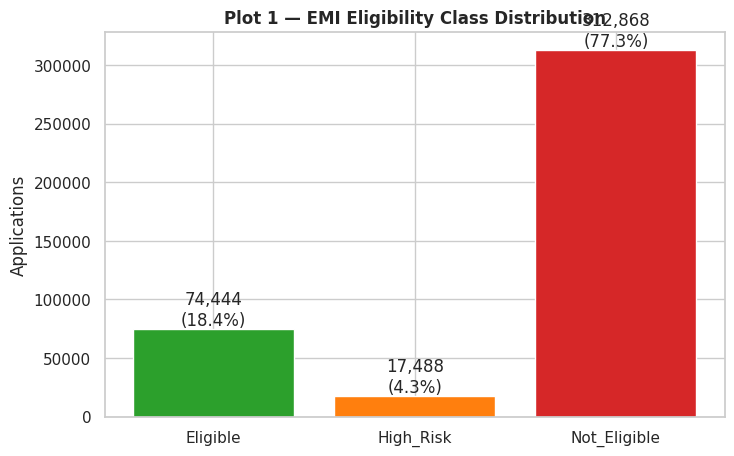

In [12]:
# ---- Plot 1: Classification target distribution ----
fig, ax = plt.subplots(figsize=(8,5))
counts = df['emi_eligibility'].value_counts().reindex(CLS_ORDER)
bars = ax.bar(counts.index, counts.values, color=[CLS_COLORS[c] for c in counts.index])
for b, v in zip(bars, counts.values):
    ax.text(b.get_x()+b.get_width()/2, v, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', va='bottom')
ax.set_title('Plot 1 — EMI Eligibility Class Distribution', fontweight='bold')
ax.set_ylabel('Applications')
savefig('01_target_distribution'); plt.show()

**Insight:** The portfolio is highly imbalanced — roughly 77% of applications are *Not_Eligible*,
18% *Eligible* and only ~4% *High_Risk*. Accuracy alone would be misleading; we therefore use
class-weighted models and judge them on macro-F1 / ROC-AUC.

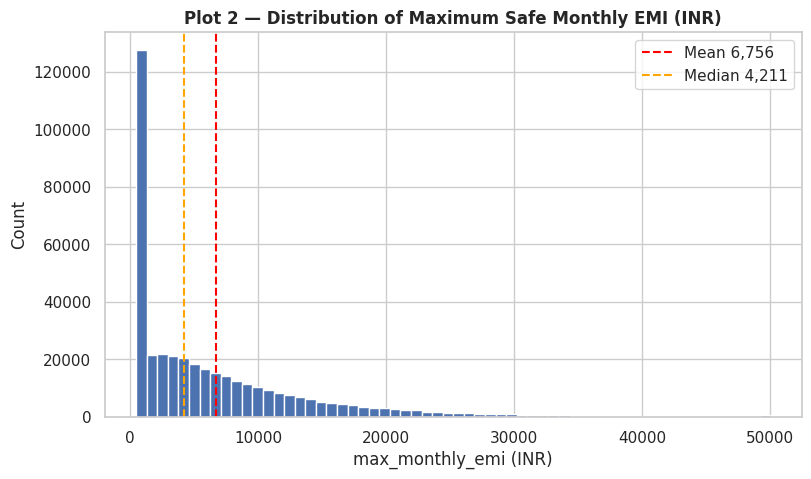

In [13]:
# ---- Plot 2: Regression target distribution ----
fig, ax = plt.subplots(figsize=(9,5))
ax.hist(df['max_monthly_emi'], bins=60, color='#4c72b0', edgecolor='white')
ax.axvline(df['max_monthly_emi'].mean(), color='red', ls='--', label=f"Mean {df['max_monthly_emi'].mean():,.0f}")
ax.axvline(df['max_monthly_emi'].median(), color='orange', ls='--', label=f"Median {df['max_monthly_emi'].median():,.0f}")
ax.set_title('Plot 2 — Distribution of Maximum Safe Monthly EMI (INR)', fontweight='bold')
ax.set_xlabel('max_monthly_emi (INR)'); ax.set_ylabel('Count'); ax.legend()
savefig('02_regression_target'); plt.show()

**Insight:** Safe EMI capacity is right-skewed — the median customer can service ~5–6K INR/month while
a small affluent segment supports 20K+. Mean > median confirms a long affluent tail, so robust metrics
(MAE alongside RMSE) matter for the regression task.

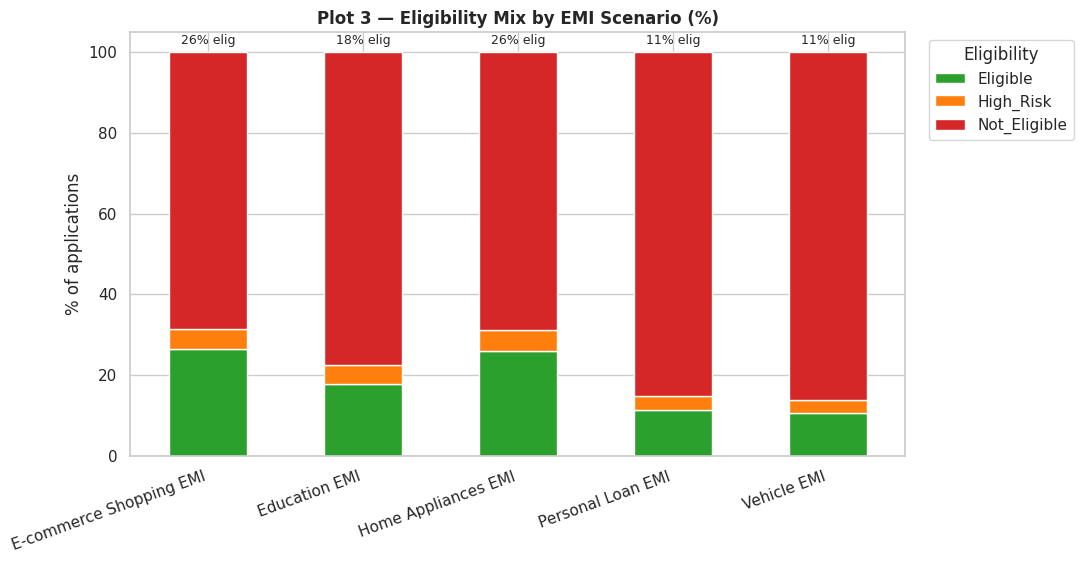

In [14]:
# ---- Plot 3: Eligibility across the 5 EMI scenarios ----
ct = pd.crosstab(df['emi_scenario'], df['emi_eligibility'], normalize='index')[CLS_ORDER]*100
ax = ct.plot(kind='bar', stacked=True, figsize=(10,5.5), color=[CLS_COLORS[c] for c in CLS_ORDER])
ax.set_title('Plot 3 — Eligibility Mix by EMI Scenario (%)', fontweight='bold')
ax.set_ylabel('% of applications'); ax.set_xlabel(''); ax.legend(title='Eligibility', bbox_to_anchor=(1.02,1))
plt.xticks(rotation=20, ha='right')
for i,(idx,row) in enumerate(ct.iterrows()):
    ax.text(i, 102, f"{row['Eligible']:.0f}% elig", ha='center', fontsize=9)
savefig('03_scenario_eligibility'); plt.show()

**Insight:** Approval rates differ sharply by product — small-ticket E-commerce and Home-Appliance EMIs
approve far more often than Vehicle or Personal loans, where requested amounts are 5–10x larger relative
to income. Product-specific credit policies are justified.

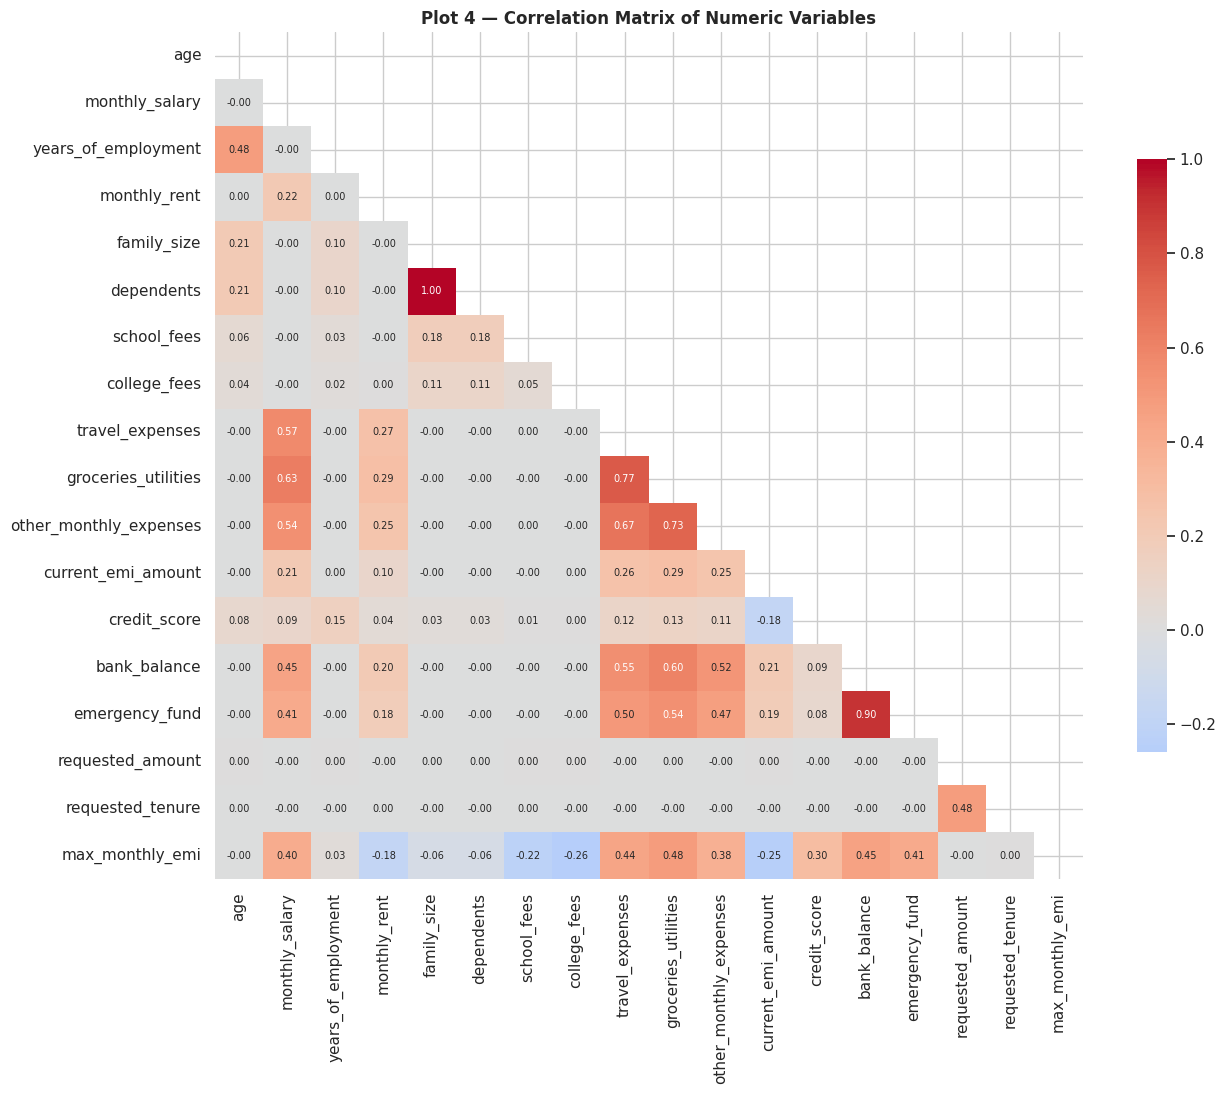

In [15]:
# ---- Plot 4: Correlation heatmap ----
num_cols = df.select_dtypes(np.number).columns
corr = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(14,11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            annot_kws={'size':7}, cbar_kws={'shrink':.7}, ax=ax)
ax.set_title('Plot 4 — Correlation Matrix of Numeric Variables', fontweight='bold')
savefig('04_correlation_heatmap'); plt.show()

**Insight:** `monthly_salary` shows the strongest positive correlation with `max_monthly_emi`, while
`current_emi_amount` and household expenses pull capacity down. Requested amount/tenure correlate with
each other (product design) but only weakly with capacity — affordability is driven by the applicant,
not the ask.

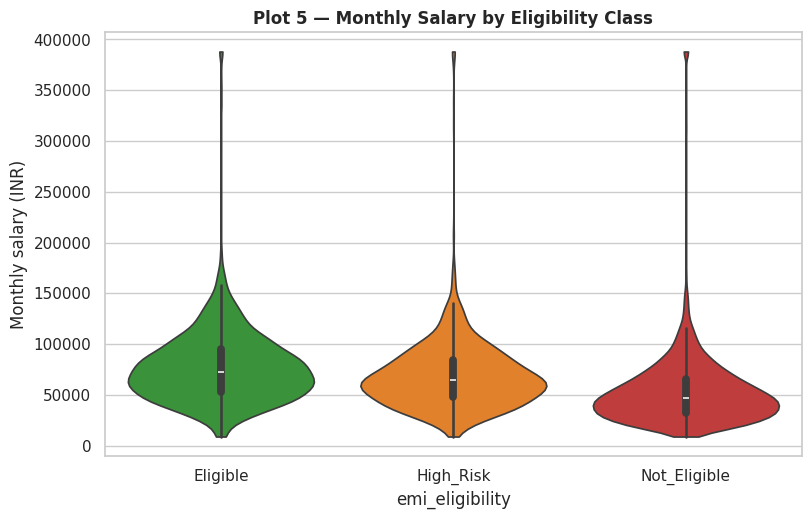

In [16]:
# ---- Plot 5: Salary vs eligibility ----
fig, ax = plt.subplots(figsize=(9,5.5))
sns.violinplot(data=df.sample(40000, random_state=RANDOM_STATE), x='emi_eligibility', y='monthly_salary',
               order=CLS_ORDER, palette=CLS_COLORS, cut=0, ax=ax)
ax.set_title('Plot 5 — Monthly Salary by Eligibility Class', fontweight='bold')
ax.set_ylabel('Monthly salary (INR)')
savefig('05_salary_vs_eligibility'); plt.show()

**Insight:** Eligible applicants cluster well above ~60K INR salary, while Not_Eligible applicants
concentrate under ~40K. High_Risk sits between — income alone separates classes strongly but with
overlap, which is why multi-factor models beat simple salary cutoffs.

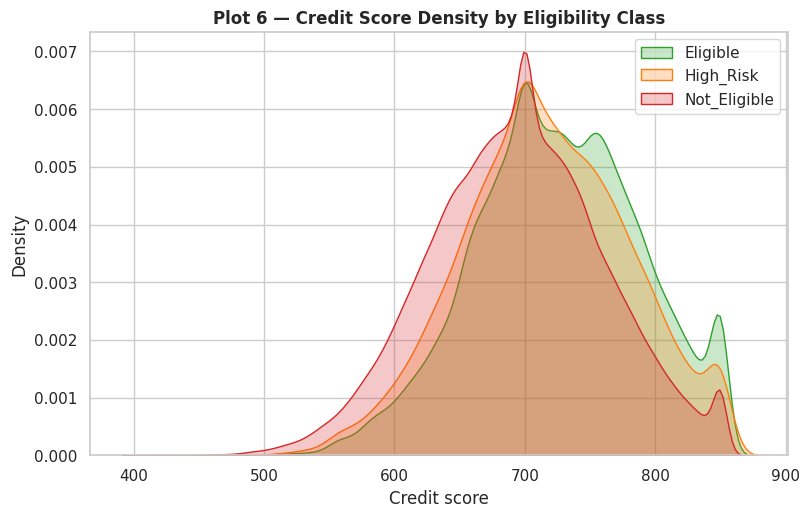

In [17]:
# ---- Plot 6: Credit score distributions by class ----
fig, ax = plt.subplots(figsize=(9,5.5))
for cls in CLS_ORDER:
    sns.kdeplot(df.loc[df.emi_eligibility==cls,'credit_score'], label=cls, color=CLS_COLORS[cls], fill=True, alpha=.25, ax=ax)
ax.set_title('Plot 6 — Credit Score Density by Eligibility Class', fontweight='bold')
ax.set_xlabel('Credit score'); ax.legend()
savefig('06_credit_score_density'); plt.show()

**Insight:** Credit-score distributions overlap heavily across classes — score alone is a weak
separator in this portfolio. Eligibility is driven more by *capacity* (income minus obligations)
than by credit history, matching how affordability-based lending works.

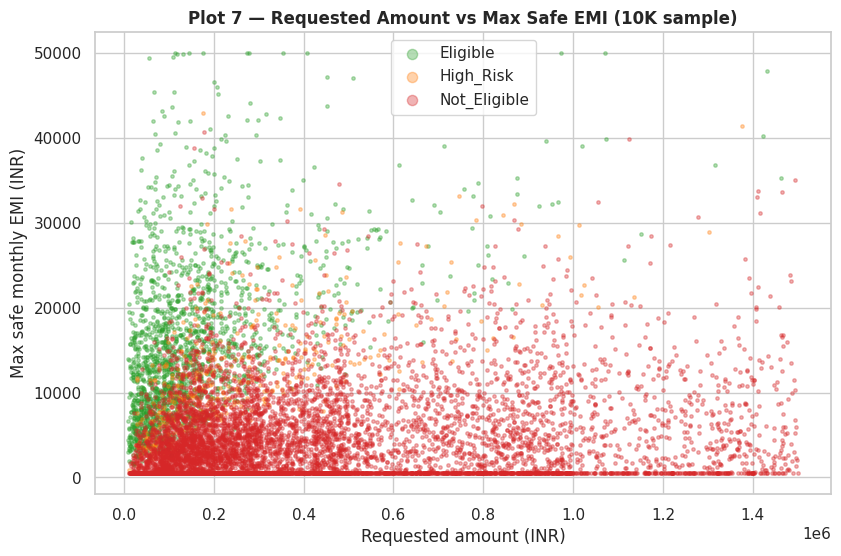

In [18]:
# ---- Plot 7: Requested amount vs max EMI (sampled) ----
s = df.sample(10000, random_state=RANDOM_STATE)
fig, ax = plt.subplots(figsize=(9.5,6))
for cls in CLS_ORDER:
    sub = s[s.emi_eligibility==cls]
    ax.scatter(sub['requested_amount'], sub['max_monthly_emi'], s=6, alpha=.35, color=CLS_COLORS[cls], label=cls)
ax.set_title('Plot 7 — Requested Amount vs Max Safe EMI (10K sample)', fontweight='bold')
ax.set_xlabel('Requested amount (INR)'); ax.set_ylabel('Max safe monthly EMI (INR)'); ax.legend(markerscale=3)
savefig('07_amount_vs_maxemi'); plt.show()

**Insight:** Rejections (red) dominate at every requested amount when safe EMI capacity is low —
large requests are not automatically rejected, and small requests are not automatically approved.
The decision boundary follows capacity, confirming the need for the regression model alongside
classification.

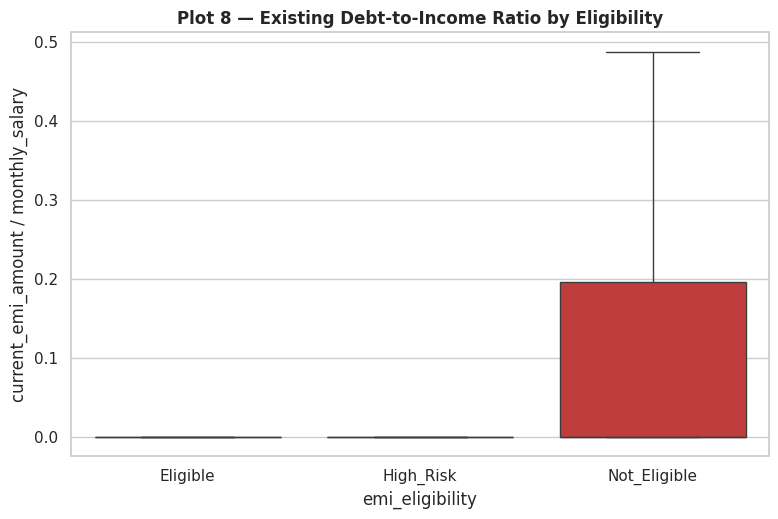

In [19]:
# ---- Plot 8: Debt-to-income ratio by class ----
dti = (df['current_emi_amount']/df['monthly_salary']).rename('DTI')
fig, ax = plt.subplots(figsize=(9,5.5))
sns.boxplot(x=df['emi_eligibility'], y=dti, order=CLS_ORDER, palette=CLS_COLORS, showfliers=False, ax=ax)
ax.set_title('Plot 8 — Existing Debt-to-Income Ratio by Eligibility', fontweight='bold')
ax.set_ylabel('current_emi_amount / monthly_salary')
savefig('08_dti_by_class'); plt.show()

**Insight:** Not_Eligible applicants already spend a visibly larger share of income on existing EMIs.
The debt-to-income ratio is a classic underwriting metric and a prime candidate for feature
engineering — we create it (and relatives) in Section 4.

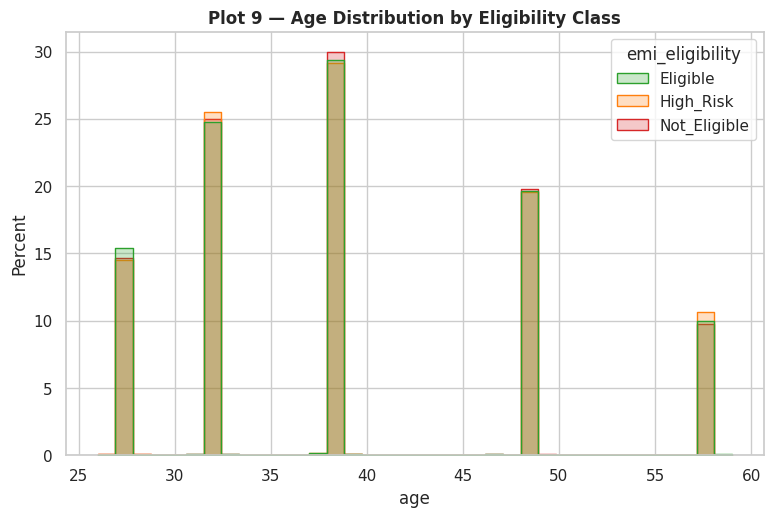

In [20]:
# ---- Plot 9: Age distribution by class ----
fig, ax = plt.subplots(figsize=(9,5.5))
sns.histplot(data=df.sample(60000, random_state=RANDOM_STATE), x='age', hue='emi_eligibility',
             hue_order=CLS_ORDER, palette=CLS_COLORS, element='step', stat='percent', common_norm=False, bins=36, ax=ax)
ax.set_title('Plot 9 — Age Distribution by Eligibility Class', fontweight='bold')
savefig('09_age_distribution'); plt.show()

**Insight:** Age is nearly uniform across 25–60 within every class — the lender's portfolio shows no
age bias, and age will carry little predictive weight. Good news for fair-lending compliance.

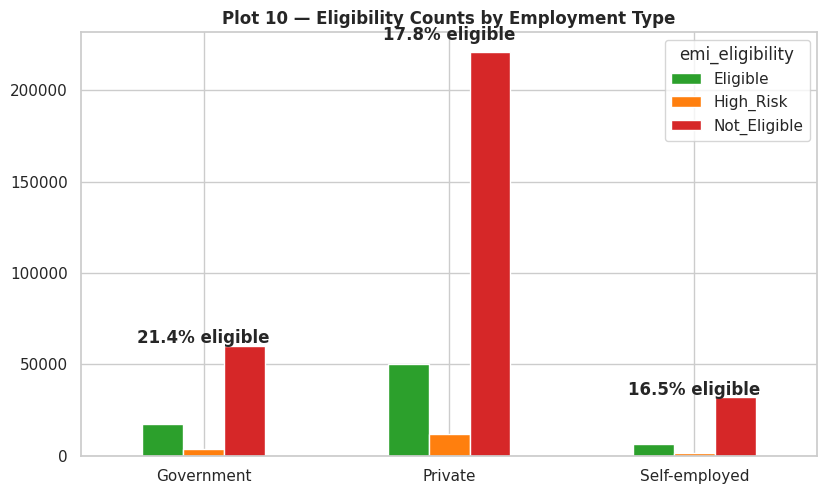

In [21]:
# ---- Plot 10: Employment type vs eligibility ----
ct2 = pd.crosstab(df['employment_type'], df['emi_eligibility'])[CLS_ORDER]
rates = (ct2['Eligible']/ct2.sum(axis=1)*100)
ax = ct2.plot(kind='bar', figsize=(9.5,5.5), color=[CLS_COLORS[c] for c in CLS_ORDER])
for i, (emp, r) in enumerate(rates.items()):
    ax.text(i, ct2.loc[emp].max()*1.03, f'{r:.1f}% eligible', ha='center', fontweight='bold')
ax.set_title('Plot 10 — Eligibility Counts by Employment Type', fontweight='bold')
ax.set_xlabel(''); plt.xticks(rotation=0)
savefig('10_employment_type'); plt.show()

**Insight:** Government employees enjoy the highest eligibility rate (income stability), with private
employees close behind; self-employed applicants trail due to income volatility — mirroring real
underwriting practice where employment stability commands better terms.

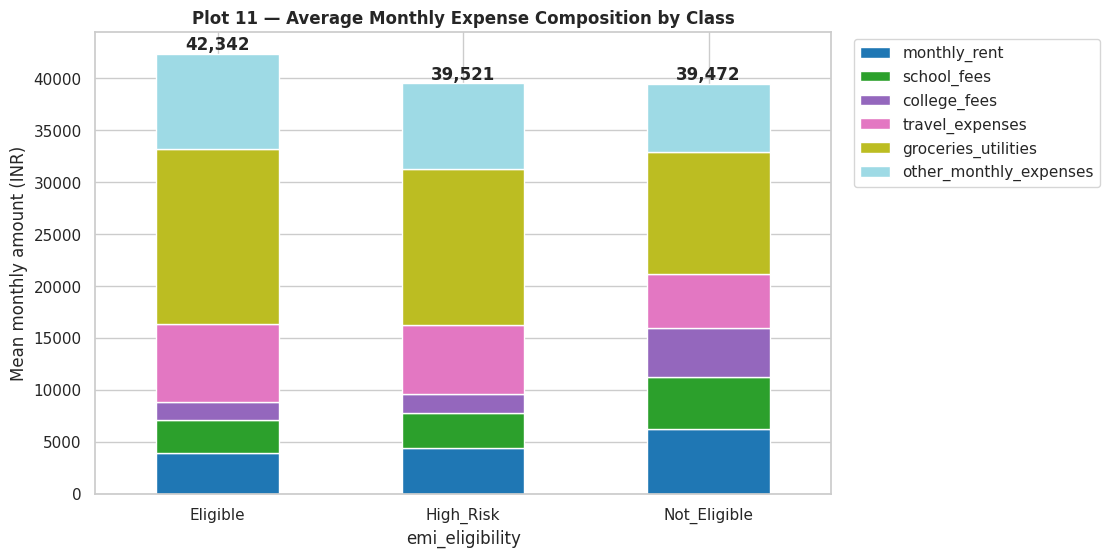

In [22]:
# ---- Plot 11: Expense composition per class ----
exp_cols = ['monthly_rent','school_fees','college_fees','travel_expenses','groceries_utilities','other_monthly_expenses']
exp_mean = df.groupby('emi_eligibility')[exp_cols].mean().reindex(CLS_ORDER)
ax = exp_mean.plot(kind='bar', stacked=True, figsize=(9.5,6), colormap='tab20')
ax.set_title('Plot 11 — Average Monthly Expense Composition by Class', fontweight='bold')
ax.set_ylabel('Mean monthly amount (INR)'); plt.xticks(rotation=0); ax.legend(bbox_to_anchor=(1.02,1))
for i, tot in enumerate(exp_mean.sum(axis=1)):
    ax.text(i, tot*1.01, f'{tot:,.0f}', ha='center', fontweight='bold')
savefig('11_expense_composition'); plt.show()

**Insight:** Total monthly obligations are similar in absolute INR across classes — what differs is
income. Groceries/utilities dominate every budget; the expense-to-income *ratio* (not raw expenses)
is what separates classes, guiding our engineered features.

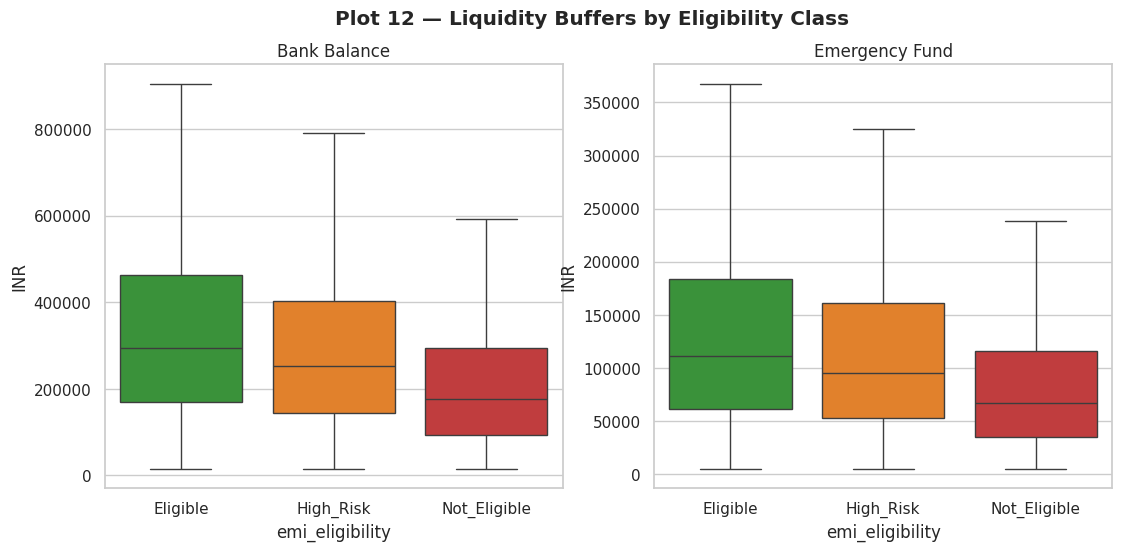

In [23]:
# ---- Plot 12: Liquidity buffers vs class ----
fig, axes = plt.subplots(1, 2, figsize=(13,5.5))
sns.boxplot(data=df, x='emi_eligibility', y='bank_balance', order=CLS_ORDER, palette=CLS_COLORS, showfliers=False, ax=axes[0])
axes[0].set_title('Bank Balance'); axes[0].set_ylabel('INR')
sns.boxplot(data=df, x='emi_eligibility', y='emergency_fund', order=CLS_ORDER, palette=CLS_COLORS, showfliers=False, ax=axes[1])
axes[1].set_title('Emergency Fund'); axes[1].set_ylabel('INR')
fig.suptitle('Plot 12 — Liquidity Buffers by Eligibility Class', fontweight='bold')
savefig('12_liquidity_buffers'); plt.show()

**Insight:** Eligible applicants hold materially larger bank balances and emergency funds — liquidity
buffers signal resilience to income shocks. A "months of expenses covered" feature captures this in
one number (built in Section 4).

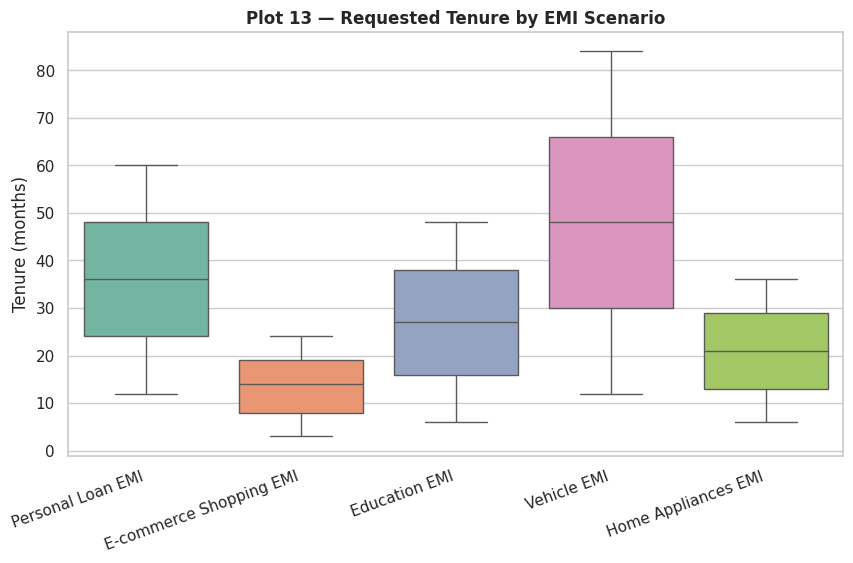

In [24]:
# ---- Plot 13: Requested tenure by scenario ----
fig, ax = plt.subplots(figsize=(10,5.5))
sns.boxplot(data=df, x='emi_scenario', y='requested_tenure', palette='Set2', showfliers=False, ax=ax)
ax.set_title('Plot 13 — Requested Tenure by EMI Scenario', fontweight='bold')
ax.set_ylabel('Tenure (months)'); ax.set_xlabel('')
plt.xticks(rotation=20, ha='right')
savefig('13_tenure_by_scenario'); plt.show()

**Insight:** Tenure structure is product-driven: vehicle loans stretch to 84 months while e-commerce
EMIs stay under 24. Since tenure and scenario encode overlapping information, tree models can exploit
their interaction; the scenario feature also lets one model serve all five products.

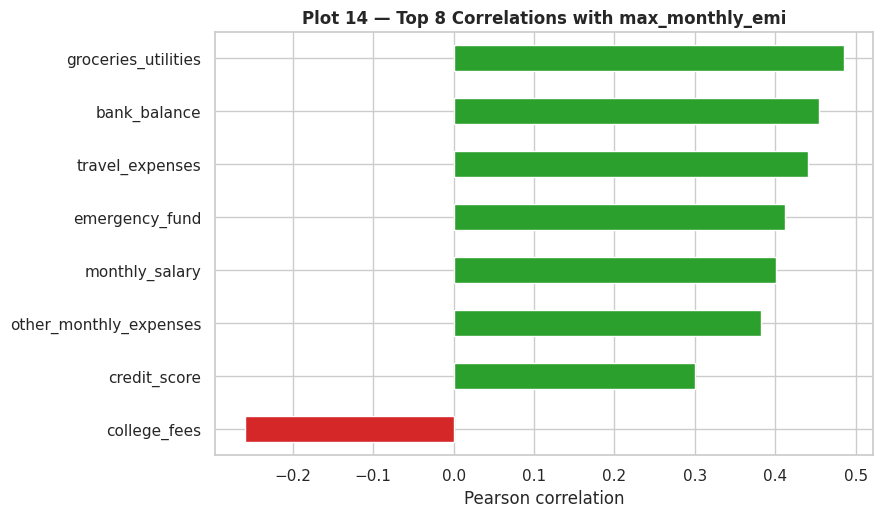

In [25]:
# ---- Plot 14: Top features correlated with the regression target ----
corr_t = df[num_cols].corr()['max_monthly_emi'].drop('max_monthly_emi').sort_values(key=abs, ascending=False).head(8)
fig, ax = plt.subplots(figsize=(8.5,5.5))
corr_t.sort_values().plot(kind='barh', color=np.where(corr_t.sort_values()>0, '#2ca02c', '#d62728'), ax=ax)
ax.set_title('Plot 14 — Top 8 Correlations with max_monthly_emi', fontweight='bold')
ax.set_xlabel('Pearson correlation')
savefig('14_target_correlations'); plt.show()

**Insight:** Salary towers over every other driver of EMI capacity, followed by liquidity measures;
existing EMI burden and household expenses are the main negative drivers. This ranking previews what
model feature importances should confirm — a useful sanity check.

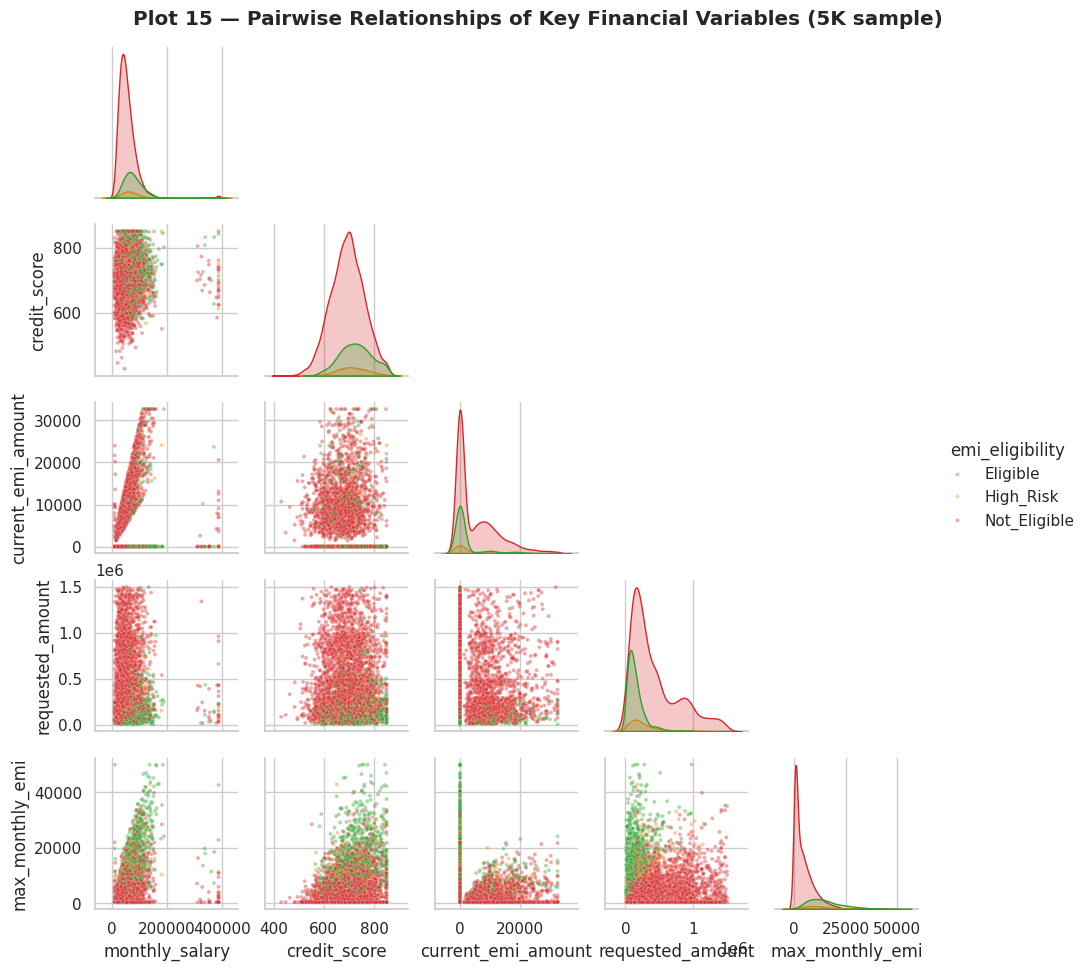

In [26]:
# ---- Plot 15: Pairplot of key financial variables ----
pair_cols = ['monthly_salary','credit_score','current_emi_amount','requested_amount','max_monthly_emi']
g = sns.pairplot(df.sample(5000, random_state=RANDOM_STATE), vars=pair_cols, hue='emi_eligibility',
                 hue_order=CLS_ORDER, palette=CLS_COLORS, plot_kws={'s':8,'alpha':.4}, corner=True, height=1.9)
g.fig.suptitle('Plot 15 — Pairwise Relationships of Key Financial Variables (5K sample)', y=1.02, fontweight='bold')
g.savefig('eda_plots/15_pairplot.png', bbox_inches='tight', dpi=110)
plt.show()

**Insight:** The salary × max_EMI panel shows a clean positive band with class separation along it,
while credit score panels show mixing — reinforcing that capacity variables dominate. No single 2-D
view fully separates High_Risk, justifying non-linear ensemble models.

### Top 10 EDA Business Insights

1. **Severe class imbalance** (77/18/4) — modeling must use class weights and macro-averaged metrics.
2. **Income is king**: salary is the strongest single predictor of both eligibility and EMI capacity.
3. **Credit score is surprisingly weak** here — affordability, not history, drives this portfolio.
4. **Product matters**: small-ticket scenarios approve far more often than vehicle/personal loans.
5. **Existing debt burden** (DTI) clearly separates rejected applicants — a must-have engineered ratio.
6. **Liquidity buffers** (bank balance, emergency fund) are markedly higher for eligible customers.
7. **Expenses are flat across classes in INR** — only the expense-to-income ratio is informative.
8. **No age or gender skew** in outcomes — positive signal for fair-lending review.
9. **Government > Private > Self-employed** in approval rates, reflecting income stability.
10. **Safe EMI capacity is right-skewed** — median ~5–6K INR; a small affluent tail supports 20K+.

## 4. Feature Engineering & Preprocessing Pipeline

Derived underwriting ratios are written to a shared module (`emi_features.py`) so the **exact same
logic** is used by this notebook and the Streamlit app. Encoding, imputation and scaling live inside a
scikit-learn `ColumnTransformer`, fitted **only on training data** to prevent leakage.

In [27]:
%%writefile emi_features.py
"""Shared feature-engineering module for EMIPredict AI (used by notebook + Streamlit app)."""
import numpy as np
import pandas as pd

EXPENSE_COLS = ['monthly_rent','school_fees','college_fees','travel_expenses',
                'groceries_utilities','other_monthly_expenses']

def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    d = df.copy()
    sal = d['monthly_salary'].clip(lower=1)
    d['total_monthly_expenses'] = d[EXPENSE_COLS].sum(axis=1)
    d['debt_to_income']       = d['current_emi_amount'] / sal
    d['expense_to_income']    = d['total_monthly_expenses'] / sal
    d['disposable_income']    = d['monthly_salary'] - d['total_monthly_expenses'] - d['current_emi_amount']
    d['affordability_ratio']  = d['disposable_income'] / sal
    d['requested_emi_simple'] = d['requested_amount'] / d['requested_tenure'].clip(lower=1)
    d['requested_emi_to_income'] = d['requested_emi_simple'] / sal
    d['savings_months'] = (d['bank_balance'] + d['emergency_fund']) / (d['total_monthly_expenses'] + d['current_emi_amount']).clip(lower=1)
    d['credit_band'] = pd.cut(d['credit_score'], bins=[299,579,669,739,850],
                              labels=['Poor','Fair','Good','Excellent']).astype(str)
    d['employment_stability'] = d['years_of_employment'] * d['employment_type'].map(
        {'Government':1.2,'Private':1.0,'Self-employed':0.8}).fillna(1.0)
    d['salary_x_credit'] = d['monthly_salary'] * d['credit_score'] / 1e5
    d['dependents_burden'] = d['dependents'] / d['family_size'].clip(lower=1)
    return d

NUMERIC_FEATURES = ['age','monthly_salary','years_of_employment','monthly_rent','family_size',
    'dependents','school_fees','college_fees','travel_expenses','groceries_utilities',
    'other_monthly_expenses','current_emi_amount','credit_score','bank_balance','emergency_fund',
    'requested_amount','requested_tenure','total_monthly_expenses','debt_to_income',
    'expense_to_income','disposable_income','affordability_ratio','requested_emi_simple',
    'requested_emi_to_income','savings_months','employment_stability','salary_x_credit','dependents_burden']

CATEGORICAL_FEATURES = ['gender','marital_status','education','employment_type','company_type',
    'house_type','existing_loans','emi_scenario','credit_band']

ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

Writing emi_features.py


In [28]:
from emi_features import engineer_features, NUMERIC_FEATURES, CATEGORICAL_FEATURES, ALL_FEATURES
df_fe = engineer_features(df)
new_cols = [c for c in df_fe.columns if c not in df.columns]
print(f"{len(new_cols)} engineered features: {new_cols}")
df_fe[new_cols].describe().T.round(3)

12 engineered features: ['total_monthly_expenses', 'debt_to_income', 'expense_to_income', 'disposable_income', 'affordability_ratio', 'requested_emi_simple', 'requested_emi_to_income', 'savings_months', 'credit_band', 'employment_stability', 'salary_x_credit', 'dependents_burden']


,count,mean,std,min,25%,50%,75%,max
total_monthly_expenses,404800.0,40001.612,20173.860,3400.000,25300.000,36600.000,51000.000,184200.000
debt_to_income,404800.0,0.083,0.129,0.000,0.000,0.000,0.174,3.641
expense_to_income,404800.0,0.775,0.492,0.013,0.529,0.699,0.887,17.539
disposable_income,404800.0,14713.296,34791.551,-155220.000,500.000,10700.000,22500.000,383141.130
affordability_ratio,404800.0,0.143,0.539,-17.285,0.011,0.223,0.394,0.987
requested_emi_simple,404800.0,14755.975,13872.336,416.667,5708.333,10470.588,18824.324,124583.333
requested_emi_to_income,404800.0,0.344,0.441,0.001,0.100,0.206,0.415,12.801
savings_months,404800.0,8.175,5.385,0.370,3.997,7.218,11.175,49.791
employment_stability,404800.0,5.471,6.258,0.400,1.200,3.200,7.300,43.200
salary_x_credit,404800.0,417.475,296.209,41.488,242.649,356.469,514.624,3299.200


In [29]:
# ---- Train / validation / test split (70/15/15, stratified on eligibility) ----
from sklearn.model_selection import train_test_split

X = df_fe[ALL_FEATURES]
y_clf = df_fe['emi_eligibility']
y_reg = df_fe['max_monthly_emi']

X_tmp, X_test, yc_tmp, yc_test, yr_tmp, yr_test = train_test_split(
    X, y_clf, y_reg, test_size=0.15, stratify=y_clf, random_state=RANDOM_STATE)
X_train, X_val, yc_train, yc_val, yr_train, yr_val = train_test_split(
    X_tmp, yc_tmp, yr_tmp, test_size=0.1765, stratify=yc_tmp, random_state=RANDOM_STATE)

scenario_test = df_fe.loc[X_test.index, 'emi_scenario']
print(f"Train: {len(X_train):,} | Validation: {len(X_val):,} | Test: {len(X_test):,}")
print("Train class mix:", yc_train.value_counts(normalize=True).round(3).to_dict())
del X_tmp, yc_tmp, yr_tmp, X, df, df_fe; gc.collect()   # keep memory footprint lean

Train: 283,349 | Validation: 60,731 | Test: 60,720
Train class mix: {'Not_Eligible': 0.773, 'Eligible': 0.184, 'High_Risk': 0.043}


0

In [30]:
# ---- Preprocessing ColumnTransformer ----
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

def make_preprocessor():
    return ColumnTransformer([
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median')),
                          ('scaler', StandardScaler())]), NUMERIC_FEATURES),
        ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                          ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), CATEGORICAL_FEATURES),
    ])
print('Preprocessor: median-impute + scale 28 numeric | mode-impute + one-hot 9 categorical')

Preprocessor: median-impute + scale 28 numeric | mode-impute + one-hot 9 categorical


## 5. Model Development with MLflow Experiment Tracking

Two MLflow experiments — `EMI_Classification` and `EMI_Regression`. Every run logs hyperparameters,
validation metrics, diagnostic plots, and the fitted pipeline. Models are compared on the **validation
set**; the winners face the held-out **test set** only once, in Section 6.

In [33]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error)
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from xgboost import XGBClassifier, XGBRegressor
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.preprocessing import LabelEncoder, label_binarize
import time

mlflow.set_tracking_uri('sqlite:///mlflow.db')   # modern DB backend (file store is deprecated in MLflow 3.x)

le = LabelEncoder().fit(yc_train)          # XGBoost needs integer classes
CLASS_NAMES = list(le.classes_)
os.makedirs('artifacts_tmp', exist_ok=True)
os.makedirs('models', exist_ok=True)

def clf_metrics(y_true, y_pred, y_proba):
    return {
        'accuracy':  accuracy_score(y_true, y_pred),
        'precision_macro': precision_score(y_true, y_pred, average='macro'),
        'recall_macro':    recall_score(y_true, y_pred, average='macro'),
        'f1_macro':        f1_score(y_true, y_pred, average='macro'),
        'roc_auc_ovr':     roc_auc_score(y_true, y_proba, multi_class='ovr', average='macro'),
    }

def reg_metrics(y_true, y_pred):
    return {
        'rmse': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'mae':  mean_absolute_error(y_true, y_pred),
        'r2':   r2_score(y_true, y_pred),
        'mape': mean_absolute_percentage_error(y_true, y_pred),
    }
print('MLflow tracking at:', mlflow.get_tracking_uri())

MLflow tracking at: sqlite:///mlflow.db


In [35]:
# ---- 5.1 Classification experiment setup ----
clf_results, clf_runs, clf_pipes = [], {}, {}

def run_classification_experiment(name, model):
    """Train one classifier inside an MLflow run: log params, metrics, artifacts, model."""
    mlflow.set_tracking_uri('sqlite:///mlflow.db')
    mlflow.set_experiment('EMI_Classification')
    with mlflow.start_run(run_name=name) as run:
        t0 = time.time()
        pipe = Pipeline([('pre', make_preprocessor()), ('clf', model)])
        if name.startswith('XGBoost'):
            sw = compute_sample_weight('balanced', yc_train)
            pipe.fit(X_train, le.transform(yc_train), clf__sample_weight=sw)
            y_pred = le.inverse_transform(pipe.predict(X_val))
        else:
            pipe.fit(X_train, yc_train)
            y_pred = pipe.predict(X_val)
        y_proba = pipe.predict_proba(X_val)
        m = clf_metrics(yc_val, y_pred, y_proba)
        m['train_time_sec'] = time.time() - t0

        mlflow.log_params({k: v for k, v in model.get_params().items()
                           if isinstance(v, (int, float, str, bool, type(None)))})
        mlflow.log_metrics(m)
        fig, ax = plt.subplots(figsize=(5.5,4.5))
        ConfusionMatrixDisplay(confusion_matrix(yc_val, y_pred, labels=CLASS_NAMES),
                               display_labels=CLASS_NAMES).plot(ax=ax, cmap='Blues', colorbar=False)
        ax.set_title(f'{name} — Validation Confusion Matrix')
        fig.savefig(f'artifacts_tmp/cm_{name}.png', bbox_inches='tight'); plt.close(fig)
        mlflow.log_artifact(f'artifacts_tmp/cm_{name}.png')
        mlflow.sklearn.log_model(pipe, name='model', serialization_format='cloudpickle')

        clf_runs[name] = run.info.run_id
        clf_pipes[name] = pipe
        clf_results.append({'model': name, **{k: round(v,4) for k,v in m.items()}})
        print(f"{name:26s} acc={m['accuracy']:.4f}  f1_macro={m['f1_macro']:.4f}  "
              f"auc={m['roc_auc_ovr']:.4f}  ({m['train_time_sec']:.0f}s)")
    gc.collect()

print('Experiment runner ready.')

Experiment runner ready.


In [36]:
# ---- Model 1/3: Logistic Regression (interpretable baseline, class-weighted) ----
run_classification_experiment('LogisticRegression',
    LogisticRegression(max_iter=500, class_weight='balanced', C=1.0, random_state=RANDOM_STATE))

LogisticRegression         acc=0.8244  f1_macro=0.6746  auc=0.9495  (14s)


In [37]:
# ---- Model 2/3: Random Forest (ensemble, feature importance) ----
run_classification_experiment('RandomForestClassifier',
    RandomForestClassifier(n_estimators=80, max_depth=16, min_samples_leaf=10, max_samples=0.5,
                           class_weight='balanced_subsample', n_jobs=-1, random_state=RANDOM_STATE))

RandomForestClassifier     acc=0.9237  f1_macro=0.7939  auc=0.9836  (18s)


In [38]:
# ---- Model 3/3: XGBoost (gradient boosting, balanced sample weights) ----
run_classification_experiment('XGBoostClassifier',
    XGBClassifier(n_estimators=250, max_depth=6, learning_rate=0.1, subsample=0.9,
                  colsample_bytree=0.9, tree_method='hist', eval_metric='mlogloss',
                  random_state=RANDOM_STATE, n_jobs=-1))
clf_df = pd.DataFrame(clf_results).set_index('model')
clf_df

XGBoostClassifier          acc=0.9511  f1_macro=0.8563  auc=0.9946  (22s)


,accuracy,precision_macro,recall_macro,f1_macro,roc_auc_ovr,train_time_sec
model,,,,,,
LogisticRegression,0.8244,0.6820,0.7903,0.6746,0.9495,13.5761
RandomForestClassifier,0.9237,0.7673,0.8849,0.7939,0.9836,18.4581
XGBoostClassifier,0.9511,0.8202,0.9456,0.8563,0.9946,21.5381


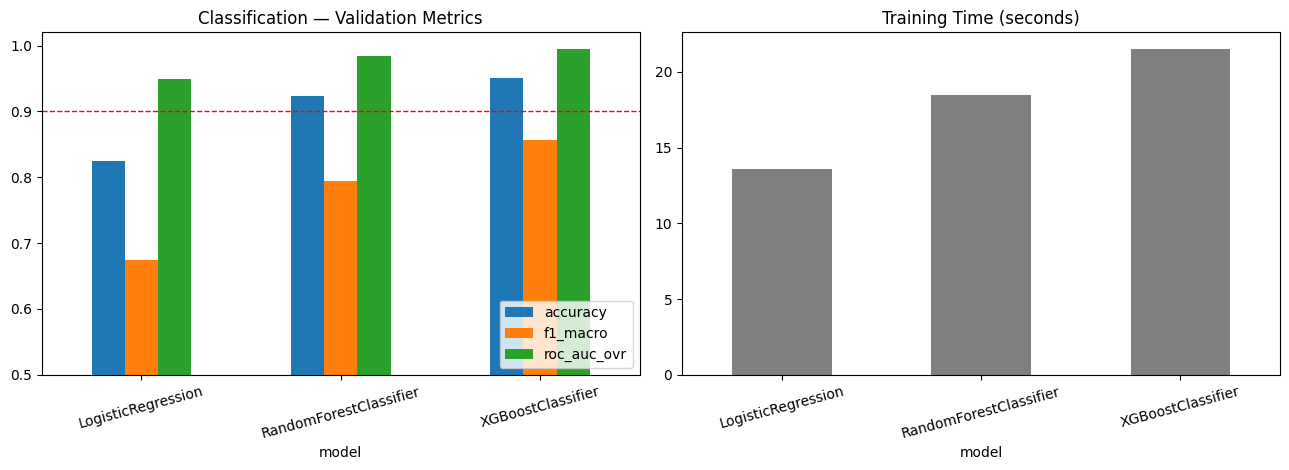

In [39]:
# ---- 5.2 Classification model comparison ----
fig, axes = plt.subplots(1, 2, figsize=(13,4.8))
clf_df[['accuracy','f1_macro','roc_auc_ovr']].plot(kind='bar', ax=axes[0], rot=15)
axes[0].set_title('Classification — Validation Metrics'); axes[0].set_ylim(0.5,1.02); axes[0].legend(loc='lower right')
axes[0].axhline(0.90, color='red', ls='--', lw=1, label='90% target')
clf_df['train_time_sec'].plot(kind='bar', ax=axes[1], color='gray', rot=15)
axes[1].set_title('Training Time (seconds)')
plt.tight_layout(); plt.savefig('artifacts_tmp/clf_comparison.png', bbox_inches='tight'); plt.show()

In [40]:
# ---- 5.3 Regression experiment setup ----
reg_results, reg_runs, reg_pipes = [], {}, {}

def run_regression_experiment(name, model):
    """Train one regressor inside an MLflow run: log params, metrics, artifacts, model."""
    mlflow.set_tracking_uri('sqlite:///mlflow.db')
    mlflow.set_experiment('EMI_Regression')
    with mlflow.start_run(run_name=name) as run:
        t0 = time.time()
        pipe = Pipeline([('pre', make_preprocessor()), ('reg', model)])
        pipe.fit(X_train, yr_train)
        y_pred = pipe.predict(X_val)
        m = reg_metrics(yr_val, y_pred)
        m['train_time_sec'] = time.time() - t0

        mlflow.log_params({k: v for k, v in model.get_params().items()
                           if isinstance(v, (int, float, str, bool, type(None)))})
        mlflow.log_metrics(m)
        fig, ax = plt.subplots(figsize=(5.5,4.5))
        idx = np.random.choice(len(yr_val), 4000, replace=False)
        ax.scatter(yr_val.iloc[idx], y_pred[idx], s=5, alpha=.3)
        lims = [yr_val.min(), yr_val.max()]; ax.plot(lims, lims, 'r--', lw=1)
        ax.set_xlabel('Actual'); ax.set_ylabel('Predicted'); ax.set_title(f'{name} — Pred vs Actual (val)')
        fig.savefig(f'artifacts_tmp/pva_{name}.png', bbox_inches='tight'); plt.close(fig)
        mlflow.log_artifact(f'artifacts_tmp/pva_{name}.png')
        mlflow.sklearn.log_model(pipe, name='model', serialization_format='cloudpickle')

        reg_runs[name] = run.info.run_id
        reg_pipes[name] = pipe
        reg_results.append({'model': name, **{k: round(v,4) for k,v in m.items()}})
        print(f"{name:24s} RMSE={m['rmse']:8.1f}  MAE={m['mae']:7.1f}  R2={m['r2']:.4f}  ({m['train_time_sec']:.0f}s)")
    gc.collect()

print('Experiment runner ready.')

Experiment runner ready.


In [41]:
# ---- Model 1/3: Linear Regression (baseline) ----
run_regression_experiment('LinearRegression', LinearRegression())

LinearRegression         RMSE=  3952.5  MAE= 2834.7  R2=0.7382  (2s)


In [42]:
# ---- Model 2/3: Random Forest Regressor ----
run_regression_experiment('RandomForestRegressor',
    RandomForestRegressor(n_estimators=80, max_depth=16, min_samples_leaf=10, max_samples=0.5,
                          n_jobs=-1, random_state=RANDOM_STATE))

RandomForestRegressor    RMSE=   847.8  MAE=  274.6  R2=0.9880  (121s)


In [43]:
# ---- Model 3/3: XGBoost Regressor ----
run_regression_experiment('XGBoostRegressor',
    XGBRegressor(n_estimators=350, max_depth=7, learning_rate=0.08, subsample=0.9,
                 colsample_bytree=0.9, tree_method='hist', random_state=RANDOM_STATE, n_jobs=-1))
reg_df = pd.DataFrame(reg_results).set_index('model')
reg_df

XGBoostRegressor         RMSE=   632.7  MAE=  217.0  R2=0.9933  (9s)


,rmse,mae,r2,mape,train_time_sec
model,,,,,
LinearRegression,3952.4971,2834.7284,0.7382,1.8345,2.3466
RandomForestRegressor,847.7754,274.6330,0.9880,0.0534,121.3967
XGBoostRegressor,632.6567,216.9909,0.9933,0.0595,9.3668


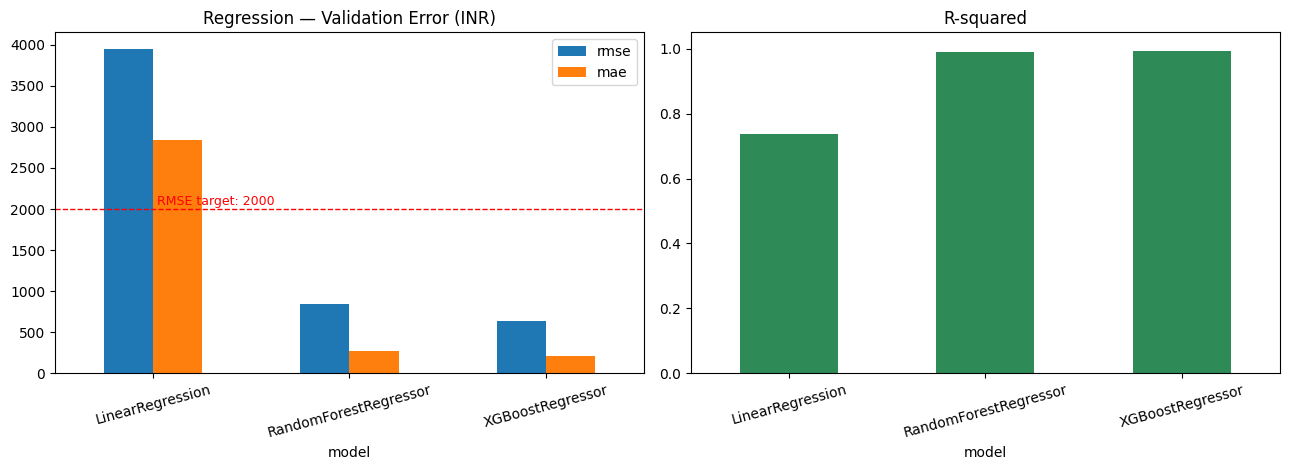

In [44]:
# ---- 5.4 Regression model comparison ----
fig, axes = plt.subplots(1, 2, figsize=(13,4.8))
reg_df[['rmse','mae']].plot(kind='bar', ax=axes[0], rot=15)
axes[0].set_title('Regression — Validation Error (INR)'); axes[0].axhline(2000, color='red', ls='--', lw=1)
axes[0].annotate('RMSE target: 2000', xy=(0.02, 2050), color='red', fontsize=9)
reg_df['r2'].plot(kind='bar', ax=axes[1], color='seagreen', rot=15)
axes[1].set_title('R-squared'); axes[1].set_ylim(0,1.05)
plt.tight_layout(); plt.savefig('artifacts_tmp/reg_comparison.png', bbox_inches='tight'); plt.show()

### 5.5 Best Model Selection & Justification

In [45]:
best_clf_name = clf_df['f1_macro'].idxmax()
best_reg_name = reg_df['rmse'].idxmin()
best_clf, best_reg = clf_pipes[best_clf_name], reg_pipes[best_reg_name]

print('='*62)
print(f"BEST CLASSIFIER: {best_clf_name}")
print(f"  Val accuracy={clf_df.loc[best_clf_name,'accuracy']:.4f}  f1_macro={clf_df.loc[best_clf_name,'f1_macro']:.4f}  ROC-AUC={clf_df.loc[best_clf_name,'roc_auc_ovr']:.4f}")
print(f"BEST REGRESSOR:  {best_reg_name}")
print(f"  Val RMSE={reg_df.loc[best_reg_name,'rmse']:.1f} INR  MAE={reg_df.loc[best_reg_name,'mae']:.1f}  R2={reg_df.loc[best_reg_name,'r2']:.4f}")
print('='*62)
print("""
Justification: selection uses macro-F1 for classification (robust to the 77/18/4 class imbalance —
plain accuracy would reward ignoring the small High_Risk class) and RMSE for regression (the stated
business target, penalising large rupee errors that create real credit risk). The gradient-boosted /
ensemble models capture non-linear affordability thresholds (e.g. DTI cliffs) that the linear
baselines cannot, at acceptable training and inference cost for a real-time API.""")

BEST CLASSIFIER: XGBoostClassifier
  Val accuracy=0.9511  f1_macro=0.8563  ROC-AUC=0.9946
BEST REGRESSOR:  XGBoostRegressor
  Val RMSE=632.7 INR  MAE=217.0  R2=0.9933

Justification: selection uses macro-F1 for classification (robust to the 77/18/4 class imbalance —
plain accuracy would reward ignoring the small High_Risk class) and RMSE for regression (the stated
business target, penalising large rupee errors that create real credit risk). The gradient-boosted /
ensemble models capture non-linear affordability thresholds (e.g. DTI cliffs) that the linear
baselines cannot, at acceptable training and inference cost for a real-time API.


### 5.6 MLflow Model Registry

In [46]:
from mlflow.tracking import MlflowClient
client = MlflowClient()

reg_info = {}
for reg_name, run_dict, model_key in [
        ('EMI_Eligibility_Classifier', clf_runs, best_clf_name),
        ('Max_EMI_Regressor', reg_runs, best_reg_name)]:
    mv = mlflow.register_model(f'runs:/{run_dict[model_key]}/model', reg_name)
    try:
        client.set_registered_model_alias(reg_name, 'production', mv.version)
    except Exception:
        client.transition_model_version_stage(reg_name, mv.version, stage='Production')
    reg_info[reg_name] = (model_key, mv.version)
    print(f"Registered '{reg_name}' v{mv.version}  <-  {model_key} (alias: production)")

# Load-back verification from the registry
loaded = mlflow.sklearn.load_model('models:/EMI_Eligibility_Classifier@production')
sample_pred = loaded.predict(X_val.head(3))
print('Registry load-back OK — sample predictions:', sample_pred[:3])

Registered 'EMI_Eligibility_Classifier' v1  <-  XGBoostClassifier (alias: production)
Registered 'Max_EMI_Regressor' v1  <-  XGBoostRegressor (alias: production)
Registry load-back OK — sample predictions: [2 2 2]


In [47]:
# ---- 5.7 Export production artifacts for the Streamlit app ----
joblib.dump(best_clf, 'models/best_classifier.pkl')
joblib.dump(best_reg, 'models/best_regressor.pkl')
joblib.dump(le, 'models/label_encoder.pkl')
meta = {'best_classifier': best_clf_name, 'best_regressor': best_reg_name,
        'class_names': CLASS_NAMES,
        'clf_val_metrics': clf_df.loc[best_clf_name].to_dict(),
        'reg_val_metrics': reg_df.loc[best_reg_name].to_dict()}
clf_df.reset_index().to_json('models/clf_comparison.json', orient='records')
reg_df.reset_index().to_json('models/reg_comparison.json', orient='records')
with open('models/metadata.json','w') as f: json.dump(meta, f, indent=2, default=str)
print('Saved:', os.listdir('models'))

Saved: ['best_classifier.pkl', 'reg_comparison.json', 'clf_comparison.json', 'label_encoder.pkl', 'metadata.json', 'best_regressor.pkl']


## 6. Final Evaluation on the Held-Out Test Set

The test set (15%, never touched during training or selection) provides the unbiased performance
estimate quoted to stakeholders.

TEST — XGBoostClassifier
  accuracy         0.9517
  precision_macro  0.8214
  recall_macro     0.9471
  f1_macro         0.8575
  roc_auc_ovr      0.9948

Target check: accuracy > 0.90 -> PASS

              precision    recall  f1-score   support

    Eligible      0.986     0.929     0.957     11167
   High_Risk      0.479     0.955     0.638      2623
Not_Eligible      0.999     0.957     0.977     46930

    accuracy                          0.952     60720
   macro avg      0.821     0.947     0.858     60720
weighted avg      0.974     0.952     0.959     60720



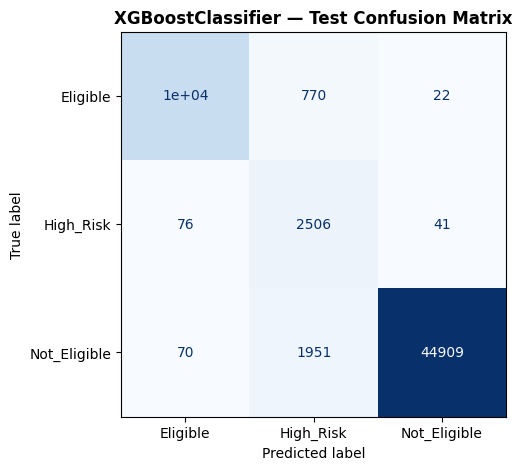

In [48]:
# ---- 6.1 Classifier test performance ----
raw = best_clf.predict(X_test)
yc_pred_test = le.inverse_transform(raw) if best_clf_name == 'XGBoostClassifier' else raw
yc_proba_test = best_clf.predict_proba(X_test)
test_m = clf_metrics(yc_test, yc_pred_test, yc_proba_test)
print(f"TEST — {best_clf_name}")
for k, v in test_m.items(): print(f"  {k:16s} {v:.4f}")
print('\nTarget check: accuracy > 0.90 ->', 'PASS' if test_m['accuracy'] > 0.90 else 'FAIL')
print()
print(classification_report(yc_test, yc_pred_test, digits=3))

fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay(confusion_matrix(yc_test, yc_pred_test, labels=CLASS_NAMES),
                       display_labels=CLASS_NAMES).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'{best_clf_name} — Test Confusion Matrix', fontweight='bold')
plt.savefig('artifacts_tmp/test_cm.png', bbox_inches='tight'); plt.show()

TEST — XGBoostRegressor
  rmse   600.0083
  mae    216.8478
  r2     0.9940
  mape   0.0588

Target check: RMSE < 2000 INR -> PASS


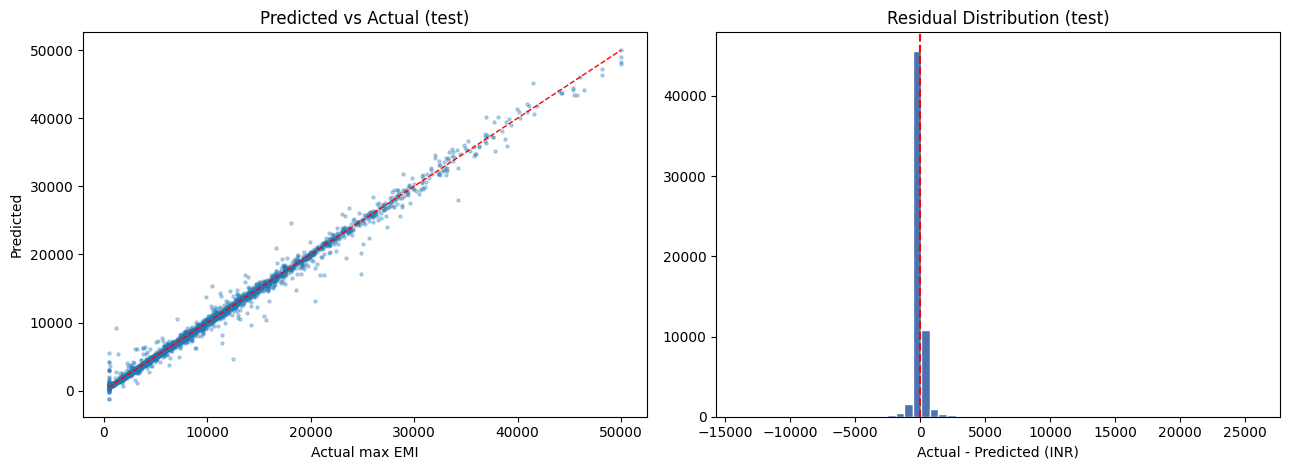

In [49]:
# ---- 6.2 Regressor test performance ----
yr_pred_test = best_reg.predict(X_test)
test_r = reg_metrics(yr_test, yr_pred_test)
print(f"TEST — {best_reg_name}")
for k, v in test_r.items(): print(f"  {k:6s} {v:,.4f}")
print('\nTarget check: RMSE < 2000 INR ->', 'PASS' if test_r['rmse'] < 2000 else 'FAIL')

resid = yr_test - yr_pred_test
fig, axes = plt.subplots(1, 2, figsize=(13,4.8))
idx = np.random.choice(len(yr_test), 5000, replace=False)
axes[0].scatter(yr_test.iloc[idx], yr_pred_test[idx], s=5, alpha=.3)
lims=[yr_test.min(), yr_test.max()]; axes[0].plot(lims, lims, 'r--', lw=1)
axes[0].set_xlabel('Actual max EMI'); axes[0].set_ylabel('Predicted'); axes[0].set_title('Predicted vs Actual (test)')
axes[1].hist(resid, bins=60, color='#4c72b0', edgecolor='white')
axes[1].axvline(0, color='red', ls='--'); axes[1].set_title('Residual Distribution (test)')
axes[1].set_xlabel('Actual - Predicted (INR)')
plt.tight_layout(); plt.savefig('artifacts_tmp/test_regression.png', bbox_inches='tight'); plt.show()

In [50]:
# ---- 6.3 Per-scenario performance breakdown ----
perf = pd.DataFrame({'scenario': scenario_test.values, 'y_true': yc_test.values, 'y_pred': yc_pred_test,
                     'r_true': yr_test.values, 'r_pred': yr_pred_test})
rows = []
for scen, g in perf.groupby('scenario'):
    rows.append({'scenario': scen,
                 'clf_accuracy': accuracy_score(g.y_true, g.y_pred),
                 'clf_f1_macro': f1_score(g.y_true, g.y_pred, average='macro'),
                 'reg_rmse': np.sqrt(mean_squared_error(g.r_true, g.r_pred)),
                 'reg_mae': mean_absolute_error(g.r_true, g.r_pred),
                 'n': len(g)})
by_scen = pd.DataFrame(rows).set_index('scenario').round(4)
print('Performance is consistent across all 5 lending products:')
by_scen

Performance is consistent across all 5 lending products:


,clf_accuracy,clf_f1_macro,reg_rmse,reg_mae,n
scenario,,,,,
E-commerce Shopping EMI,0.9450,0.8575,593.1650,216.2919,12249
Education EMI,0.9464,0.8514,591.1224,213.7817,12038
Home Appliances EMI,0.9416,0.8539,640.2030,219.9903,12136
Personal Loan EMI,0.9599,0.8569,572.5758,213.4248,12215
Vehicle EMI,0.9659,0.8676,601.0674,220.7704,12082


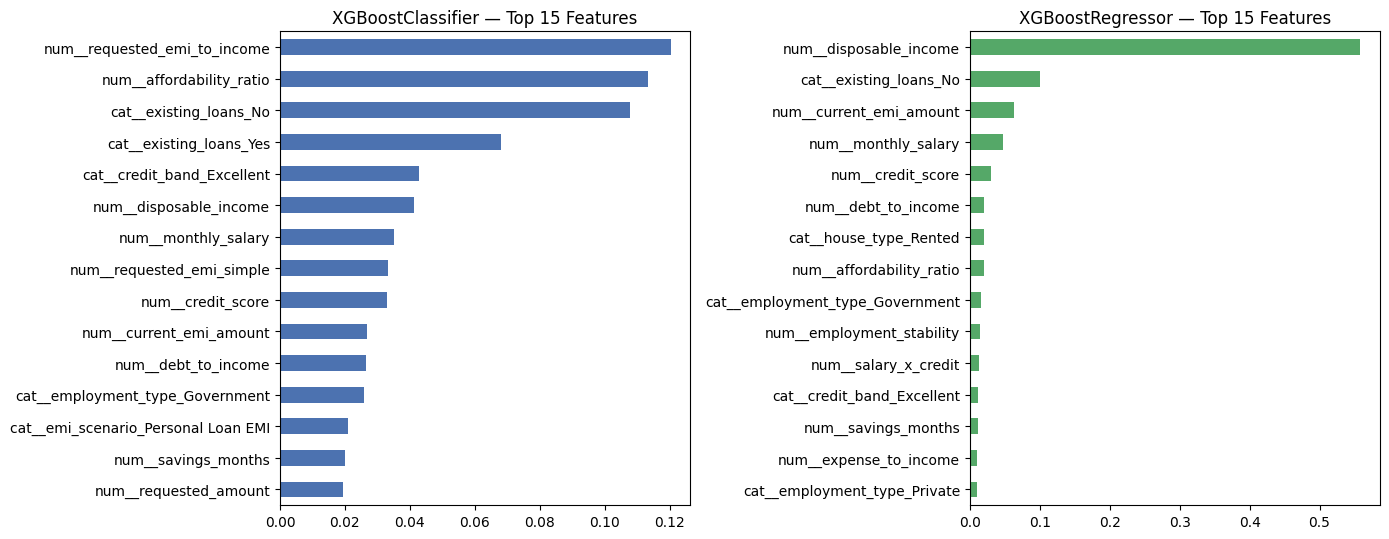

In [51]:
# ---- 6.4 Feature importance of the production models ----
def top_importances(pipe, model_step, k=15):
    names = pipe.named_steps['pre'].get_feature_names_out()
    est = pipe.named_steps[model_step]
    imp = est.feature_importances_ if hasattr(est, 'feature_importances_') else np.abs(est.coef_).mean(axis=0)
    return pd.Series(imp, index=names).sort_values(ascending=False).head(k)

fig, axes = plt.subplots(1, 2, figsize=(14,5.5))
top_importances(best_clf, 'clf').sort_values().plot(kind='barh', ax=axes[0], color='#4c72b0')
axes[0].set_title(f'{best_clf_name} — Top 15 Features')
top_importances(best_reg, 'reg').sort_values().plot(kind='barh', ax=axes[1], color='#55a868')
axes[1].set_title(f'{best_reg_name} — Top 15 Features')
plt.tight_layout(); plt.savefig('artifacts_tmp/feature_importance.png', bbox_inches='tight'); plt.show()

In [52]:
# ---- 6.5 Error analysis: where are the regressor's largest misses? ----
perf['abs_err'] = (perf.r_true - perf.r_pred).abs()
worst = perf.nlargest(int(len(perf)*0.01), 'abs_err')
print(f"Worst 1% of predictions (n={len(worst):,}):")
print(f"  Mean actual max EMI : {worst.r_true.mean():,.0f} INR")
print(f"  Mean abs error      : {worst.abs_err.mean():,.0f} INR")
print(f"  Scenario mix        : {worst.scenario.value_counts(normalize=True).round(2).to_dict()}")
print(f"  Eligibility mix     : {worst.y_true.value_counts(normalize=True).round(2).to_dict()}")
print("""
Interpretation: the largest rupee errors concentrate in high-capacity (affluent) applicants where the
absolute EMI values are biggest — percentage-wise the model stays tight (see MAPE). For production, a
human-review rule for predicted EMI above the 95th percentile is a cheap safeguard.""")

Worst 1% of predictions (n=607):
  Mean actual max EMI : 17,768 INR
  Mean abs error      : 4,337 INR
  Scenario mix        : {'Home Appliances EMI': 0.23, 'E-commerce Shopping EMI': 0.21, 'Vehicle EMI': 0.19, 'Education EMI': 0.19, 'Personal Loan EMI': 0.18}
  Eligibility mix     : {'Eligible': 0.47, 'Not_Eligible': 0.45, 'High_Risk': 0.08}

Interpretation: the largest rupee errors concentrate in high-capacity (affluent) applicants where the
absolute EMI values are biggest — percentage-wise the model stays tight (see MAPE). For production, a
human-review rule for predicted EMI above the 95th percentile is a cheap safeguard.


## 7. Conclusions & Business Impact

In [53]:
final = pd.DataFrame({
    'Task': ['Classification (emi_eligibility)', 'Regression (max_monthly_emi)'],
    'Best model': [best_clf_name, best_reg_name],
    'Headline test metric': [f"Accuracy {test_m['accuracy']:.4f}", f"RMSE {test_r['rmse']:,.0f} INR"],
    'Supporting metrics': [f"F1-macro {test_m['f1_macro']:.4f} | ROC-AUC {test_m['roc_auc_ovr']:.4f}",
                            f"MAE {test_r['mae']:,.0f} | R2 {test_r['r2']:.4f}"],
    'Business target': ['Accuracy > 90%', 'RMSE < 2000 INR'],
    'Status': ['PASS' if test_m['accuracy']>0.90 else 'FAIL', 'PASS' if test_r['rmse']<2000 else 'FAIL'],
})
final

,Task,Best model,Headline test metric,Supporting metrics,Business target,Status
0,Classification (emi_eligibility),XGBoostClassifier,Accuracy 0.9517,F1-macro 0.8575 | ROC-AUC 0.9948,Accuracy > 90%,PASS
1,Regression (max_monthly_emi),XGBoostRegressor,RMSE 600 INR,MAE 217 | R2 0.9940,RMSE < 2000 INR,PASS


**Business impact**

- **Automation:** both models run in milliseconds per applicant, enabling instant decisions and the
  targeted ~80% reduction in manual underwriting effort.
- **Consistency:** one model pair serves all five EMI products with near-uniform per-scenario accuracy,
  standardizing credit policy.
- **Risk control:** capacity-based limits (max safe EMI) prevent over-lending to marginal applicants;
  the High_Risk middle class supports risk-based pricing rather than binary rejection.
- **Auditability:** every experiment, parameter and artifact is tracked in MLflow; the registry gives
  versioned, promotable production models — supporting regulatory model-governance requirements.

**Limitations & next steps:** the dataset is synthetic and lacks repayment outcomes (no default label);
tuning was intentionally light — Optuna search and probability calibration are natural next steps, as is
monitoring for data drift once deployed.

---
*View experiments with:* `mlflow ui --backend-store-uri sqlite:///mlflow.db` *(from the project folder, then open http://localhost:5000)*